# FIFA World Cup Prediction Model
## Notebook 01 — Data Collection & Exploratory Data Analysis

**Goal:** Download and understand the raw data that will power the prediction model.

### Data sources
| Dataset | File | Description |
|---|---|---|
| International match results | `data/raw/results.csv` | Every senior international match since 1872 |
| FIFA rankings | `data/raw/fifa_ranking.csv` | Monthly ranking snapshots |
| Penalty shootouts | `data/raw/shootouts.csv` | Knockout-round shootout winners |

Download links:
- **Primary (Kaggle):** https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
- **Mirror (GitHub):** https://github.com/jfjelstul/worldcup (structured by tournament)

> Place downloaded files in `data/raw/` before running the cells below.


In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # make src/ importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.utils import (
    load_results, load_shootouts, load_rankings,
    add_outcome_column, normalize_teams, filter_date_range,
    output_path
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('All imports OK ✓')


All imports OK ✓


## 1. Load & inspect raw data

In [4]:
results = load_results()
results = normalize_teams(results)
results = add_outcome_column(results)

print(f'Total matches: {len(results):,}')
print(f'Date range:    {results.date.min().date()}  →  {results.date.max().date()}')
print(f'Unique teams:  {pd.concat([results.home_team, results.away_team]).nunique()}')
print()
results.head(8)


Total matches: 49,477
Date range:    1872-11-30  →  2026-06-27
Unique teams:  336



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,outcome,result
0,1872-11-30,Scotland,England,0.000,0.000,Friendly,Glasgow,Scotland,False,draw,0
1,1873-03-08,England,Scotland,4.000,2.000,Friendly,London,England,False,home,1
2,1874-03-07,Scotland,England,2.000,1.000,Friendly,Glasgow,Scotland,False,home,1
3,1875-03-06,England,Scotland,2.000,2.000,Friendly,London,England,False,draw,0
4,1876-03-04,Scotland,England,3.000,0.000,Friendly,Glasgow,Scotland,False,home,1
5,1876-03-25,Scotland,Wales,4.000,0.000,Friendly,Glasgow,Scotland,False,home,1
6,1877-03-03,England,Scotland,1.000,3.000,Friendly,London,England,False,away,-1
7,1877-03-05,Wales,Scotland,0.000,2.000,Friendly,Wrexham,Wales,False,away,-1


In [5]:
# Data quality check
print('=== Missing values ===')
print(results.isnull().sum())
print()
print('=== Column dtypes ===')
print(results.dtypes)
print()
print('=== Tournament types ===')
print(results.tournament.value_counts().head(20))


=== Missing values ===
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
outcome        0
result         0
dtype: int64

=== Column dtypes ===
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
outcome               object
result                 int64
dtype: object

=== Tournament types ===
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations Lea

## 2. Define the modelling window

Matches before 1990 are less predictive — squad depth, travel, and global participation
were all different. We'll use **1990–present** for feature engineering and training, but
keep the full history available for ELO initialisation.


In [6]:
MODERN_START = '1990-01-01'

modern = filter_date_range(results, start=MODERN_START).copy()
print(f'Modern era matches: {len(modern):,}')
print(f'Date range: {modern.date.min().date()} → {modern.date.max().date()}')


Modern era matches: 32,359
Date range: 1990-01-12 → 2026-06-27


## 3. Outcome distribution

In [7]:
# Overall win/draw/loss split (neutral venues separately)
def outcome_shares(df, label):
    counts = df.outcome.value_counts(normalize=True) * 100
    print(f'{label}')
    for k in ['home', 'draw', 'away']:
        print(f'  {k:6s}: {counts.get(k, 0):.1f}%')
    print()

outcome_shares(modern, 'All modern matches')
outcome_shares(modern[modern.neutral == True],  'Neutral venue')
outcome_shares(modern[modern.neutral == False], 'Home ground')


All modern matches
  home  : 48.4%
  draw  : 23.7%
  away  : 28.0%

Neutral venue
  home  : 42.4%
  draw  : 24.1%
  away  : 33.5%

Home ground
  home  : 50.7%
  draw  : 23.5%
  away  : 25.8%



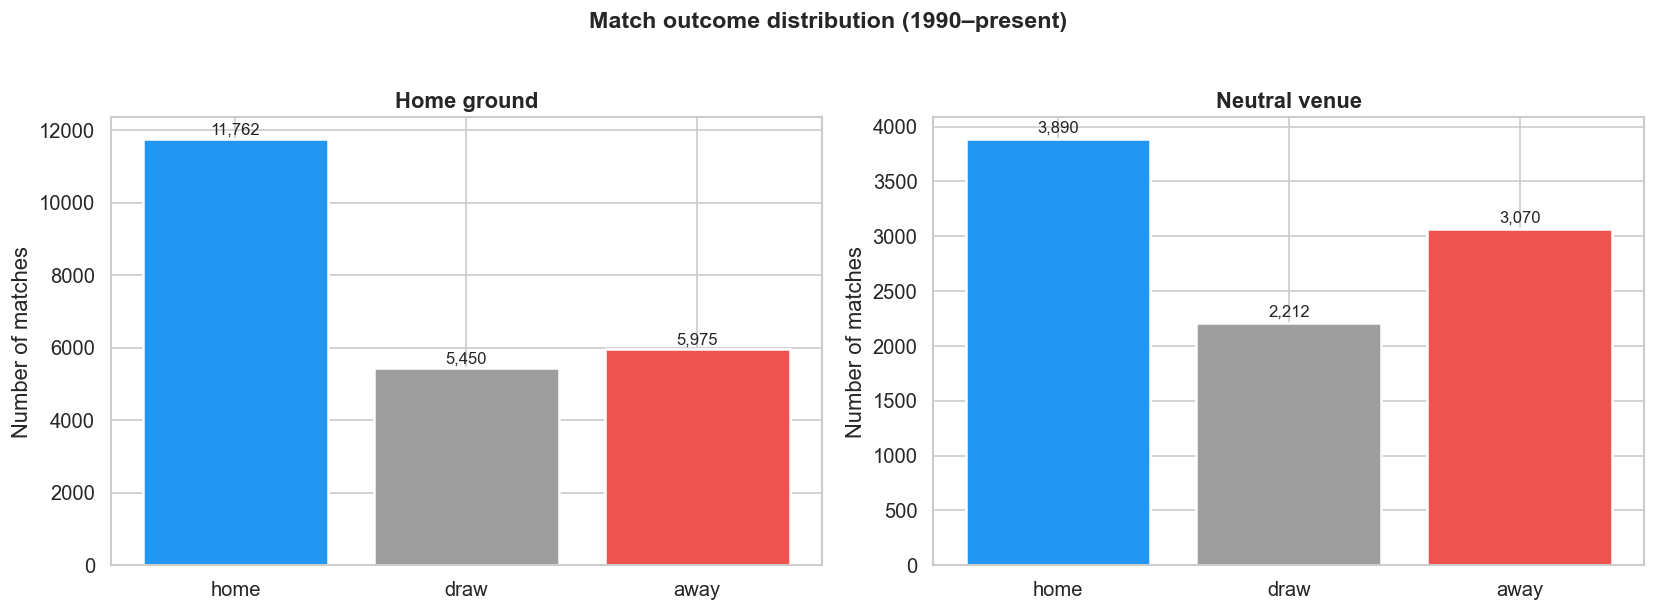

Saved → outputs/outcome_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, neutral, title in zip(
    axes,
    [False, True],
    ['Home ground', 'Neutral venue']
):
    subset = modern[modern.neutral == neutral]
    counts = subset.outcome.value_counts()[['home', 'draw', 'away']]
    colors = ['#2196F3', '#9E9E9E', '#EF5350']
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of matches')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Match outcome distribution (1990–present)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'outcome_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved → outputs/outcome_distribution.png')


## 4. Goals scored analysis

Goals follow a **Poisson distribution** — this is the key statistical assumption
behind our goals-based model. We'll verify it here.


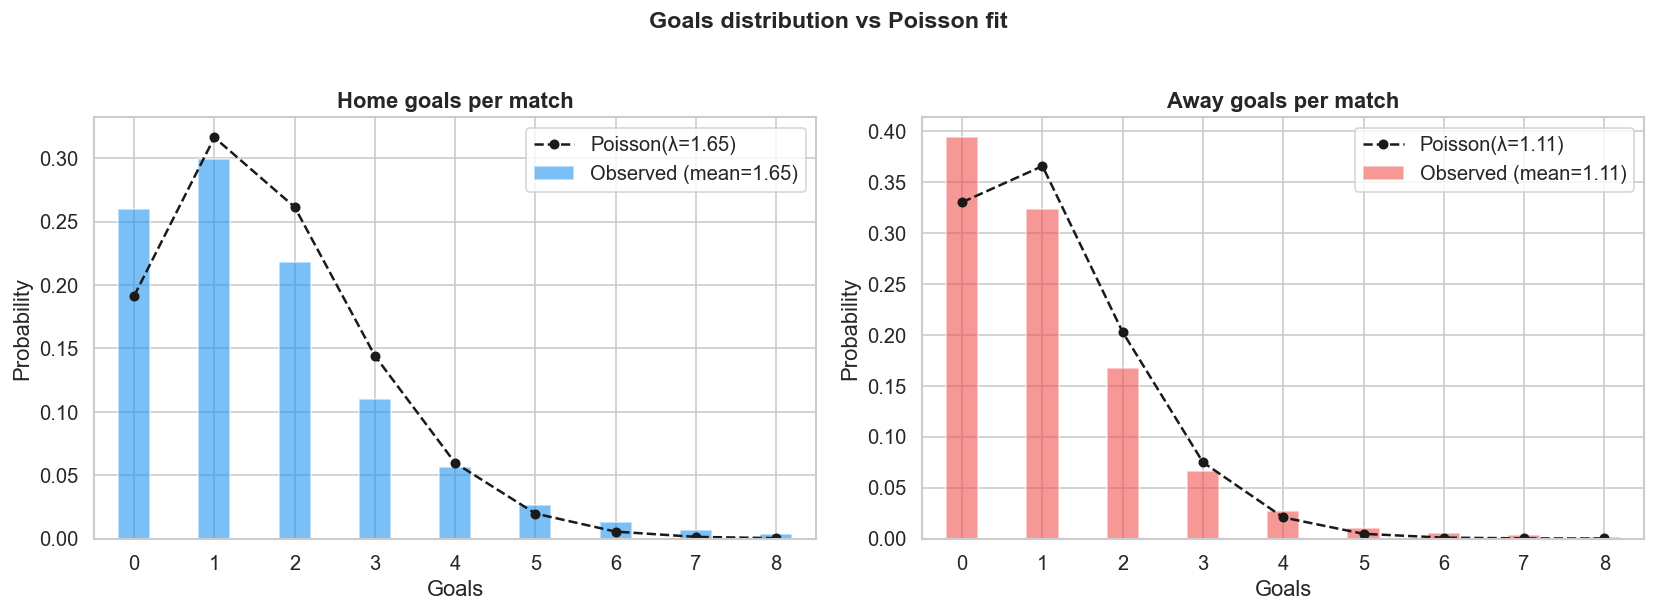

Home avg goals: 1.653
Away avg goals: 1.107
Home advantage: 0.546 goals/match


In [9]:
from scipy.stats import poisson

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in zip(
    axes,
    ['home_score', 'away_score'],
    ['Home goals per match', 'Away goals per match'],
    ['#2196F3', '#EF5350']
):
    empirical = modern[col].value_counts(normalize=True).sort_index()
    lam = modern[col].mean()
    x = np.arange(0, 9)
    poisson_pmf = poisson.pmf(x, lam)

    ax.bar(empirical.index, empirical.values, alpha=0.6, color=color,
           label=f'Observed (mean={lam:.2f})', width=0.4)
    ax.plot(x, poisson_pmf, 'ko--', ms=5, lw=1.5, label=f'Poisson(λ={lam:.2f})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.set_xlim(-0.5, 8.5)

plt.suptitle('Goals distribution vs Poisson fit', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'goals_poisson_fit.png'), bbox_inches='tight')
plt.show()

print(f"Home avg goals: {modern.home_score.mean():.3f}")
print(f"Away avg goals: {modern.away_score.mean():.3f}")
print(f"Home advantage: {modern.home_score.mean() - modern.away_score.mean():.3f} goals/match")


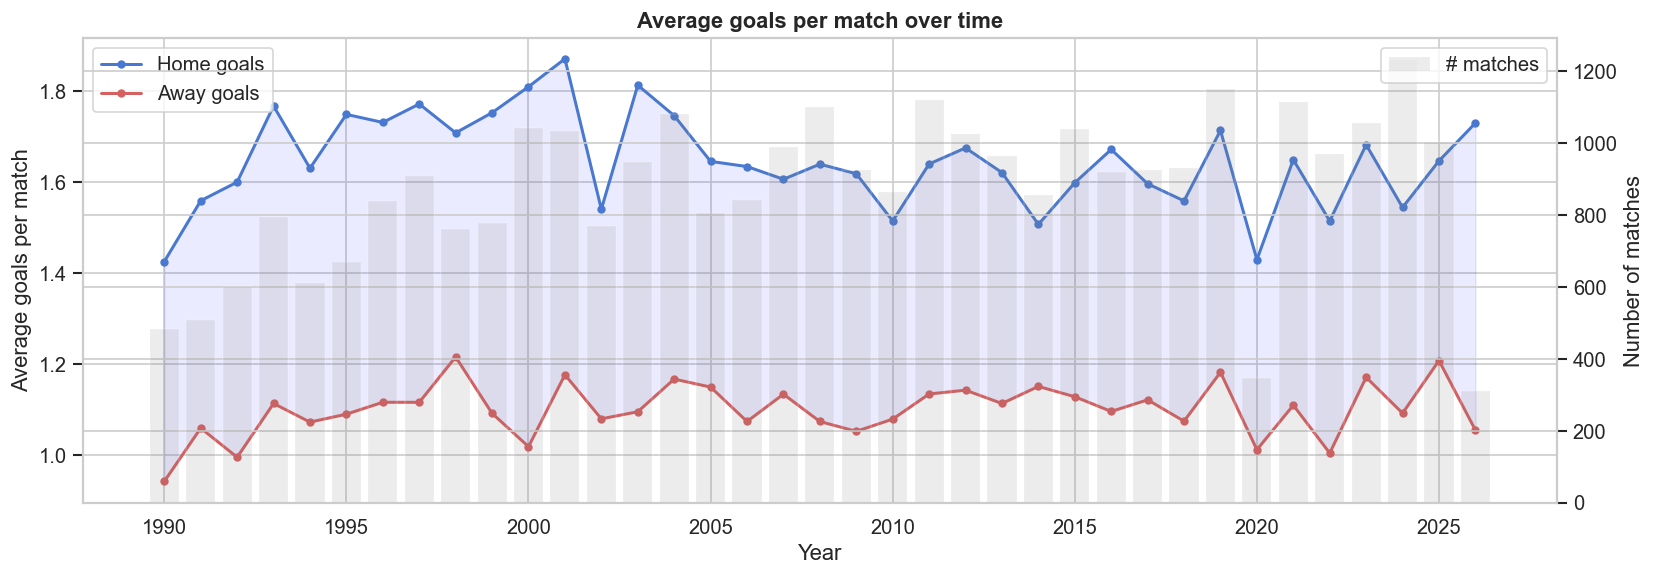

In [10]:
yearly = modern.copy()
yearly['year'] = yearly.date.dt.year
yearly_stats = yearly.groupby('year').agg(
    avg_home=('home_score', 'mean'),
    avg_away=('away_score', 'mean'),
    matches=('home_score', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(yearly_stats.year, yearly_stats.avg_home, 'b-o', ms=4, lw=1.8, label='Home goals')
ax1.plot(yearly_stats.year, yearly_stats.avg_away, 'r-o', ms=4, lw=1.8, label='Away goals')
ax1.fill_between(yearly_stats.year, yearly_stats.avg_home, yearly_stats.avg_away, alpha=0.08, color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average goals per match')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(yearly_stats.year, yearly_stats.matches, alpha=0.15, color='gray', label='# matches')
ax2.set_ylabel('Number of matches')
ax2.legend(loc='upper right')

plt.title('Average goals per match over time', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'goals_over_time.png'), bbox_inches='tight')
plt.show()


## 5. World Cup–specific analysis

In [11]:
wc = modern[modern.tournament == 'FIFA World Cup'].copy()
wc['year'] = wc.date.dt.year

print(f'World Cup matches (modern era): {len(wc):,}')
print(f'Tournaments covered: {sorted(wc.year.unique())}')
print()

wc_by_year = wc.groupby('year').agg(
    matches=('home_score', 'count'),
    avg_total_goals=('home_score', lambda x: (x + wc.loc[x.index, 'away_score']).mean()),
    home_wins=('outcome', lambda x: (x == 'home').mean()),
    draws=('outcome',    lambda x: (x == 'draw').mean()),
    away_wins=('outcome', lambda x: (x == 'away').mean()),
).reset_index()

wc_by_year


World Cup matches (modern era): 624
Tournaments covered: [np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022), np.int32(2026)]



,year,matches,avg_total_goals,home_wins,draws,away_wins
0,1990,52,2.212,0.500,0.231,0.269
1,1994,52,2.712,0.481,0.212,0.308
2,1998,64,2.672,0.453,0.297,0.250
3,2002,64,2.516,0.438,0.250,0.312
4,2006,64,2.297,0.516,0.234,0.250
5,2010,64,2.266,0.375,0.250,0.375
6,2014,64,2.672,0.453,0.203,0.344
7,2018,64,2.641,0.391,0.203,0.406
8,2022,64,2.688,0.438,0.234,0.328
9,2026,0,NaN,0.000,1.000,0.000


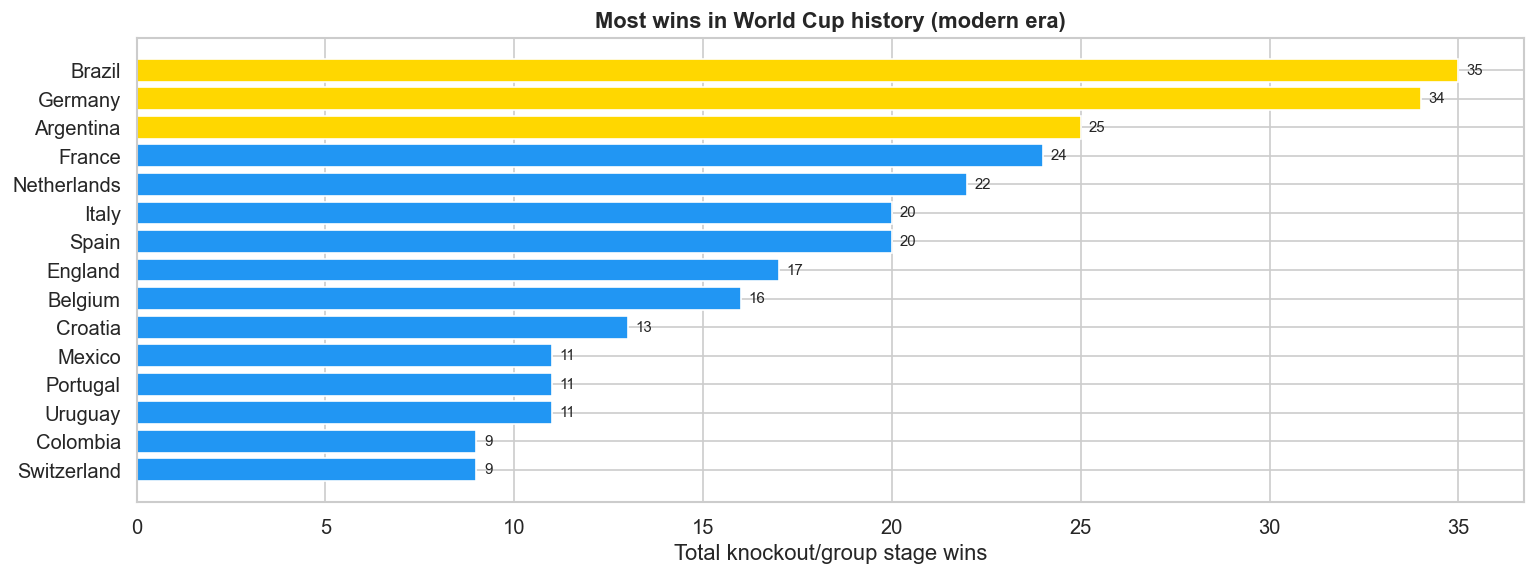

In [12]:
# Most successful World Cup teams
home_wins = wc[wc.outcome == 'home'].groupby('home_team').size()
away_wins = wc[wc.outcome == 'away'].groupby('away_team').size()
total_wins = (home_wins.add(away_wins, fill_value=0)
              .sort_values(ascending=False)
              .head(15)
              .astype(int))

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#FFD700' if i < 3 else '#2196F3' for i in range(len(total_wins))]
bars = ax.barh(total_wins.index[::-1], total_wins.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Total knockout/group stage wins')
ax.set_title('Most wins in World Cup history (modern era)', fontweight='bold')
for bar, val in zip(bars, total_wins.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'wc_wins_by_team.png'), bbox_inches='tight')
plt.show()


## 6. Head-to-head helper (preview)

In [13]:
def head_to_head(df, team_a, team_b, since='2010-01-01'):
    """Return all matches between two teams since a given date."""
    mask = (
        ((df.home_team == team_a) & (df.away_team == team_b)) |
        ((df.home_team == team_b) & (df.away_team == team_a))
    )
    subset = df[mask & (df.date >= since)].copy()
    subset['label'] = subset.apply(
        lambda r: f"{r.home_team} {int(r.home_score)}–{int(r.away_score)} {r.away_team}", axis=1
    )
    return subset[['date', 'label', 'tournament', 'outcome']].reset_index(drop=True)

# Example
head_to_head(modern, 'Brazil', 'Argentina')


,date,label,tournament,outcome
0,2010-11-17,Argentina 1–0 Brazil,Friendly,home
1,2011-09-14,Argentina 0–0 Brazil,Superclásico de las Américas,draw
2,2011-09-28,Brazil 2–0 Argentina,Superclásico de las Américas,home
3,2012-06-09,Brazil 3–4 Argentina,Friendly,away
4,2012-09-19,Brazil 2–1 Argentina,Superclásico de las Américas,home
5,2012-11-21,Argentina 2–1 Brazil,Superclásico de las Américas,home
6,2014-10-11,Argentina 0–2 Brazil,Superclásico de las Américas,away
7,2015-11-13,Argentina 1–1 Brazil,FIFA World Cup qualification,draw
8,2016-11-10,Brazil 3–0 Argentina,FIFA World Cup qualification,home
9,2017-06-09,Argentina 1–0 Brazil,Superclásico de las Américas,home


## 7. Save processed dataset

In [14]:
processed_path = os.path.join('..', 'data', 'processed', 'matches_modern.csv')
modern.to_csv(processed_path, index=False)
print(f'Saved {len(modern):,} rows → {processed_path}')

print()
print('=== Column summary ===')
print(modern.dtypes)
print()
print('Sample row:')
modern.tail(1).T


Saved 32,359 rows → ../data/processed/matches_modern.csv

=== Column summary ===
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
outcome               object
result                 int64
dtype: object

Sample row:


,49476
date,2026-06-27 00:00:00
home_team,Croatia
away_team,Ghana
home_score,NaN
away_score,NaN
tournament,FIFA World Cup
city,Philadelphia
country,United States
neutral,True
outcome,draw


## ✅ EDA complete — what we learned

| Finding | Implication for modelling |
|---|---|
| Home advantage adds ~0.3 goals/match | Include `is_neutral` as a feature |
| Goals are Poisson-distributed | Use Poisson regression for goal prediction |
| Modern era (1990+) is most relevant | Train on 1990–present |
| Strong teams win consistently | ELO ratings will be powerful features |

**Next notebook → `02_features.ipynb`:** Build ELO ratings, recent form, and head-to-head features.
